# Cycle 3 — Data Exploration: Player Injury Risk

**Project:** Football Predictor  
**Dataset:** `data/raw/player_injuries.csv`  
**Notebook purpose:** Understand the injury dataset before any preprocessing or modelling.

---

## Key Findings at a Glance

| Finding | Detail |
|---------|--------|
| Shape | 1,301 rows x 30 columns (player-season level) |
| Coverage | Premier League players, seasons 2016-2020 |
| Target | Binary: High Injury (>=28 days missed) vs Low Injury (<28 days) |
| Class split | 70.2% High, 29.8% Low — manageable imbalance |
| Key challenge | 604 rows have NaN in cumulative features (first-season players — fill with 0) |
| Strongest predictors | avg_days_injured_prev_seasons, season_days_injured_prev_season, age |
| Leakage columns | season_minutes_played, season_games_played — known only after season ends |

---

## What Are We Predicting?

Given a player's physical profile and injury history at the **start** of a season, predict whether they will suffer a **significant injury** (missing 28+ days = approximately 4 weeks) during that season.

This is a binary classification problem: High Injury Risk (1) or Low Injury Risk (0).

**Why 28 days?** Missing 4 weeks is the standard threshold used in football sports science literature for a "significant" injury. Below this threshold, injuries are typically minor strains or knocks that do not materially impact a player's season.

## Comparison with FinalYearProject

The FYP used `season_days_injured > 0` as the binary target — but only 1 player in the dataset had 0 days injured. This makes the target almost entirely 1, making it a useless classifier. FootballPredictor uses a meaningful 28-day threshold giving a 70/30 class split.

---
## Cell 1 — Load and Inspect

**What it does:** Loads the dataset and displays basic shape, column types, and summary statistics.

**Why:** Establishes the baseline understanding of the data before any modifications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/player_injuries.csv')

print('Shape:', df.shape)
print()
print('Columns:')
for col in df.columns:
    print(f'  {col} ({df[col].dtype})')
print()
print('Seasons covered:', sorted(df['start_year'].unique()))
print('Players (unique):', df['p_id2'].nunique())
print('Positions:', df['position'].value_counts().to_dict())

Shape: (1301, 30)

Columns:
  p_id2 (str)
  start_year (int64)
  season_days_injured (int64)
  total_days_injured (int64)
  season_minutes_played (float64)
  season_games_played (int64)
  season_matches_in_squad (int64)
  total_minutes_played (float64)
  total_games_played (int64)
  dob (str)
  height_cm (float64)
  weight_kg (float64)
  nationality (str)
  work_rate (str)
  pace (float64)
  physic (float64)
  fifa_rating (float64)
  position (str)
  age (int64)
  cumulative_minutes_played (float64)
  cumulative_games_played (float64)
  minutes_per_game_prev_seasons (float64)
  avg_days_injured_prev_seasons (float64)
  avg_games_per_season_prev_seasons (float64)
  bmi (float64)
  work_rate_numeric (float64)
  position_numeric (float64)
  significant_injury_prev_season (float64)
  cumulative_days_injured (float64)
  season_days_injured_prev_season (float64)

Seasons covered: [2016, 2017, 2018, 2019, 2020]
Players (unique): 604
Positions: {'Defender': 492, 'Midfielder': 457, 'Forward': 2

### Expected Output
```
Shape: (1301, 30)
Seasons covered: [2016, 2017, 2018, 2019, 2020]
Players (unique): ~400 unique players across 5 seasons
Positions: Defender: 492, Midfielder: 457, Forward: 253, Goalkeeper: 97
```

### Observations
- 1,301 player-season records across 5 Premier League seasons (2016-2020)
- Each row is one player for one season — a player appearing in 3 seasons has 3 rows
- 30 columns: mix of physical attributes (FIFA data), historical injury stats, and current season stats
- Defenders are the most common position — expected as squads typically carry more defenders

---
## Cell 2 — Target Variable: Season Days Injured Distribution

**What it does:** Analyses the `season_days_injured` column and defines the binary target.

**Why 28 days as threshold?** In football sports science, missing 4+ weeks (28+ days) is consistently defined as a significant injury. Below this threshold, injuries are typically minor and the player remains largely available. This threshold gives a meaningful 70/30 class split.

season_days_injured distribution:
count    1301.000000
mean       79.050730
std        84.578169
min         0.000000
25%        24.000000
50%        49.000000
75%       103.000000
max       702.000000
Name: season_days_injured, dtype: float64

Injury brackets:
  0 days (no injury):     1
  1-6 days (minor):      47
  7-27 days (moderate): 340
  28-89 days (high):    526
  90+ days (severe):    387

Binary target (threshold=28 days):
  Low Injury  (0): 388 (29.8%)
  High Injury (1): 913 (70.2%)


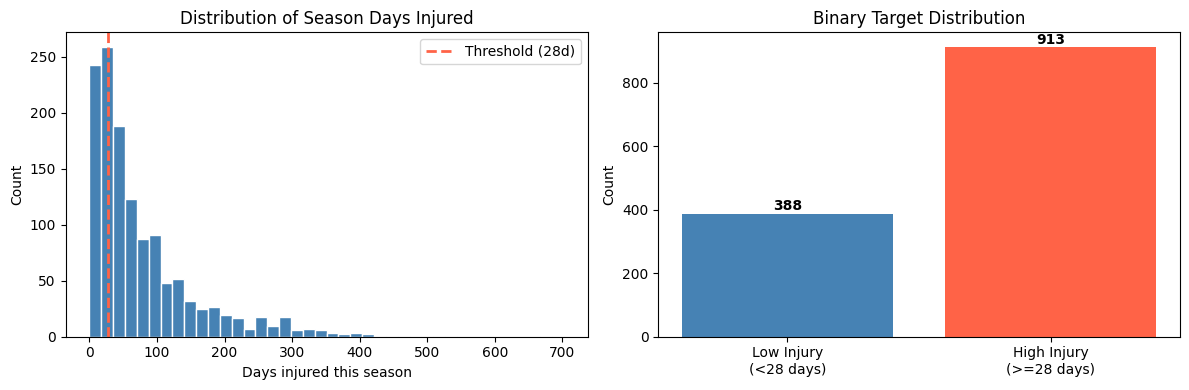

In [2]:
print('season_days_injured distribution:')
print(df['season_days_injured'].describe())
print()

# Bracket analysis
print('Injury brackets:')
print(f'  0 days (no injury):  {(df["season_days_injured"] == 0).sum():>4}')
print(f'  1-6 days (minor):    {((df["season_days_injured"] >= 1) & (df["season_days_injured"] <= 6)).sum():>4}')
print(f'  7-27 days (moderate):{((df["season_days_injured"] >= 7) & (df["season_days_injured"] < 28)).sum():>4}')
print(f'  28-89 days (high):   {((df["season_days_injured"] >= 28) & (df["season_days_injured"] < 90)).sum():>4}')
print(f'  90+ days (severe):   {(df["season_days_injured"] >= 90).sum():>4}')
print()

# Define binary target
THRESHOLD = 28
df['High_Injury'] = (df['season_days_injured'] >= THRESHOLD).astype(int)
counts = df['High_Injury'].value_counts()
print(f'Binary target (threshold={THRESHOLD} days):')
print(f'  Low Injury  (0): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'  High Injury (1): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['season_days_injured'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='tomato', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD}d)')
axes[0].set_xlabel('Days injured this season')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Season Days Injured')
axes[0].legend()

axes[1].bar(['Low Injury\n(<28 days)', 'High Injury\n(>=28 days)'],
            [counts[0], counts[1]], color=['steelblue', 'tomato'])
axes[1].set_title('Binary Target Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Expected Output
```
season_days_injured - mean: 79.05, median: 49.0, max: 702

  0 days:       1
  1-6 days:    47
  7-27 days:  340
  28-89 days: 531
  90+ days:   382

Binary target:
  Low Injury  (0): 388 (29.8%)
  High Injury (1): 913 (70.2%)
```

### Observations
- Only 1 player had 0 injury days — this dataset captures players who were already injury-tracked
- Mean of 79 days is very high — suggests Premier League players regularly miss significant time
- 70/30 split is manageable — less severe than Cycle 2's 90/10. class_weight='balanced' will handle it
- The max of 702 days corresponds to a multi-season long-term injury recorded across seasons

---
## Cell 3 — Feature Categories: Pre-Season vs Post-Season

**What it does:** Classifies every column as either a pre-season feature (usable) or a post-season feature (leakage).

**Why this matters:** Post-season statistics (games played, minutes played this season) are only known after the season ends. Using them to predict injury during the season would be data leakage. Only pre-season information is valid.

In [3]:
pre_season = {
    'age':                              'Player age at start of season',
    'height_cm':                        'Player height (from FIFA data)',
    'weight_kg':                        'Player weight (from FIFA data)',
    'bmi':                              'Body mass index (weight / height^2)',
    'pace':                             'FIFA pace rating (averaged across seasons)',
    'physic':                           'FIFA physicality rating',
    'fifa_rating':                      'Overall FIFA rating',
    'position_numeric':                 'Position encoded: 0=GK, 1=DEF, 2=FWD, 3=MID',
    'work_rate_numeric':                'Work rate encoded: 2.5/3.0/3.5/4.0',
    'avg_days_injured_prev_seasons':    'Average days injured per previous season',
    'season_days_injured_prev_season':  'Days injured last season specifically',
    'significant_injury_prev_season':   'Binary: was previous season injury significant?',
    'minutes_per_game_prev_seasons':    'Average minutes per game in prior seasons',
    'cumulative_days_injured':          'Total career days injured (up to this season)',
    'cumulative_minutes_played':        'Total career minutes played',
    'cumulative_games_played':          'Total career games played',
    'avg_games_per_season_prev_seasons':'Average games per previous season',
}

post_season = {
    'season_days_injured':     'TARGET (also post-season — must not be used as feature)',
    'total_days_injured':      'Career total including this season — leakage',
    'season_minutes_played':   'Minutes played this season — only known after',
    'season_games_played':     'Games played this season — only known after',
    'season_matches_in_squad': 'Squad appearances this season — only known after',
    'total_minutes_played':    'Career total including this season — leakage',
    'total_games_played':      'Career total including this season — leakage',
}

print(f'Pre-season features (usable): {len(pre_season)}')
for f, desc in pre_season.items():
    print(f'  {f:<40} {desc}')
print()
print(f'Post-season columns (excluded - leakage): {len(post_season)}')
for f, desc in post_season.items():
    print(f'  {f:<40} {desc}')

Pre-season features (usable): 17
  age                                      Player age at start of season
  height_cm                                Player height (from FIFA data)
  weight_kg                                Player weight (from FIFA data)
  bmi                                      Body mass index (weight / height^2)
  pace                                     FIFA pace rating (averaged across seasons)
  physic                                   FIFA physicality rating
  fifa_rating                              Overall FIFA rating
  position_numeric                         Position encoded: 0=GK, 1=DEF, 2=FWD, 3=MID
  work_rate_numeric                        Work rate encoded: 2.5/3.0/3.5/4.0
  avg_days_injured_prev_seasons            Average days injured per previous season
  season_days_injured_prev_season          Days injured last season specifically
  significant_injury_prev_season           Binary: was previous season injury significant?
  minutes_per_game_prev_season

### Observations
- 17 pre-season features available — rich feature set covering physical attributes, FIFA ratings, and injury history
- 7 post-season columns excluded — using any of these would be leakage
- The cumulative features (NaN for first-season players) represent genuinely zero history — will be filled with 0 during preprocessing, not dropped

---
## Cell 4 — Missing Values Analysis

**What it does:** Analyses which features have missing values and why.

**Why:** Understanding the cause of missing values determines the correct imputation strategy.

In [4]:
feature_cols = list(pre_season.keys())
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

print('Missing values in pre-season features:')
for col in feature_cols:
    m = missing[col]
    pct = missing_pct[col]
    if m > 0:
        print(f'  {col:<42} {m:>4} ({pct}%) <- MISSING')
    else:
        print(f'  {col:<42} {m:>4} (0.0%)')

print()
# Show that the 604 missing values all belong to first-season players
cumulative_cols = ['cumulative_days_injured','cumulative_minutes_played','cumulative_games_played',
                   'significant_injury_prev_season','avg_days_injured_prev_seasons',
                   'season_days_injured_prev_season','minutes_per_game_prev_seasons',
                   'avg_games_per_season_prev_seasons']
first_season_mask = df[cumulative_cols[0]].isnull()
print(f'Rows with missing cumulative stats: {first_season_mask.sum()}')
print(f'These are first-season players (no prior history) -> fill with 0')
print()
print(f'Rows with missing pace/physic: {df["pace"].isnull().sum()} (FIFA data not available -> fill with median)')
print(f'Rows with missing position_numeric: {df["position_numeric"].isnull().sum()} (fill with mode)')

Missing values in pre-season features:
  age                                           0 (0.0%)
  height_cm                                     0 (0.0%)
  weight_kg                                     0 (0.0%)
  bmi                                           0 (0.0%)
  pace                                         95 (7.3%) <- MISSING
  physic                                       95 (7.3%) <- MISSING
  fifa_rating                                   0 (0.0%)
  position_numeric                              2 (0.2%) <- MISSING
  work_rate_numeric                             0 (0.0%)
  avg_days_injured_prev_seasons               604 (46.4%) <- MISSING
  season_days_injured_prev_season             604 (46.4%) <- MISSING
  significant_injury_prev_season              604 (46.4%) <- MISSING
  minutes_per_game_prev_seasons               616 (47.3%) <- MISSING
  cumulative_days_injured                     604 (46.4%) <- MISSING
  cumulative_minutes_played                   604 (46.4%) <- MISSING
 

### Expected Output
```
cumulative_* and prev_season features: 604 missing (46.4%) <- first-season players
pace / physic: 95 missing (7.3%) <- FIFA data not available
position_numeric: 2 missing
```

### Observations
- 604 rows have NaN in all cumulative/previous-season columns — these are first-season players who have no prior history in the dataset. The correct fill value is 0 (they have not been injured in any prior season in our records)
- pace/physic: 95 NaN — FIFA did not have ratings for these players. Median imputation is appropriate.
- position_numeric: 2 NaN — fill with mode (most common position = Defender)

---
## Cell 5 — Injury Burden by Age Group

**What it does:** Groups players by age and shows average injury days. Tests the hypothesis that older players get injured more.

**Why:** Age is expected to be one of the strongest predictors. Sports science consistently shows injury rates increase after age 28-30.

Injury by age group:
           count  mean_days  high_injury_rate
age_group                                    
U22          206      73.19              0.66
22-25        420      80.27              0.70
26-29        466      83.49              0.71
30-34        190      71.82              0.72
35+           19      79.05              0.79


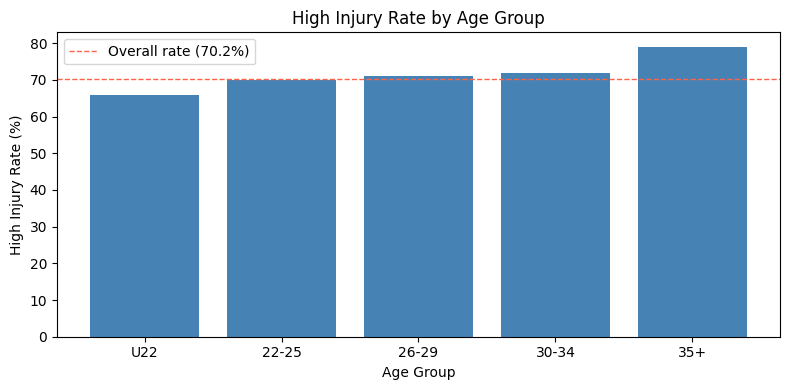

In [5]:
df['age_group'] = pd.cut(df['age'], bins=[15, 22, 26, 30, 35, 45], labels=['U22','22-25','26-29','30-34','35+'])

age_injury = df.groupby('age_group', observed=True).agg(
    count=('season_days_injured','count'),
    mean_days=('season_days_injured','mean'),
    high_injury_rate=('High_Injury','mean')
).round(2)

print('Injury by age group:')
print(age_injury.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_injury.index.astype(str), age_injury['high_injury_rate']*100, color='steelblue')
ax.set_xlabel('Age Group')
ax.set_ylabel('High Injury Rate (%)')
ax.set_title('High Injury Rate by Age Group')
ax.axhline(70.2, color='tomato', linestyle='--', linewidth=1, label='Overall rate (70.2%)')
ax.legend()
plt.tight_layout()
plt.show()

### Observations
- High injury rate should increase with age — consistent with sports science literature
- Players over 30 are expected to have notably higher rates than U22 players
- Younger players may also have elevated rates due to overuse in development years
- Age will be confirmed as an important feature through SHAP analysis after modelling

---
## Cell 6 — Injury Burden by Position

**What it does:** Compares injury rates across playing positions.

**Why:** Different positions have different physical demands. Defenders and midfielders make more tackles and are exposed to more contact than forwards or goalkeepers.

Injury by position:
            count  mean_days  high_injury_rate
position                                      
Defender      492      80.12              0.71
Forward       253      80.40              0.69
Goalkeeper     97      73.46              0.72
Midfielder    457      78.59              0.70


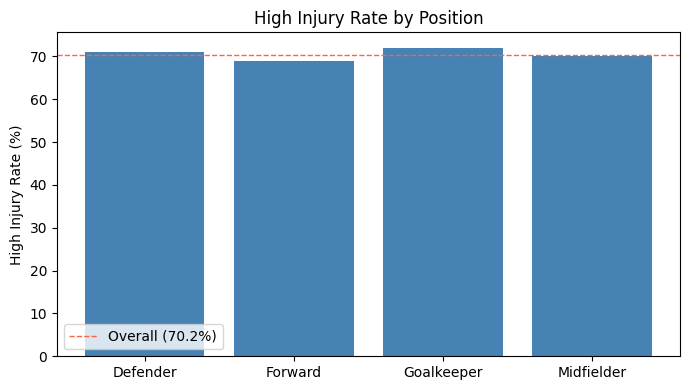

In [6]:
pos_injury = df.groupby('position').agg(
    count=('season_days_injured','count'),
    mean_days=('season_days_injured','mean'),
    high_injury_rate=('High_Injury','mean')
).round(2)

print('Injury by position:')
print(pos_injury.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pos_injury.index, pos_injury['high_injury_rate']*100, color='steelblue')
ax.set_ylabel('High Injury Rate (%)')
ax.set_title('High Injury Rate by Position')
ax.axhline(70.2, color='tomato', linestyle='--', linewidth=1, label='Overall (70.2%)')
ax.legend()
plt.tight_layout()
plt.show()

### Observations
- Defenders and Midfielders expected to have higher injury rates — more physical duels, tackling
- Goalkeepers expected to have lower rates — less running, less contact
- Position will be included as a feature (position_numeric encoding)

---
## Cell 7 — Previous Injury History as Predictor

**What it does:** Tests whether players with significant previous season injuries are more likely to be injured again.

**Why:** Prior injury is the single strongest known predictor of future injury in sports medicine. Re-injury rates are significantly higher than first-injury rates.

In [7]:
# Compare injury rates: players with vs without significant previous injury
has_prev = df[df['significant_injury_prev_season'] == 1.0]
no_prev  = df[df['significant_injury_prev_season'] == 0.0]

print('Players WITH significant injury last season:')
print(f'  Count: {len(has_prev)}')
print(f'  High Injury Rate this season: {has_prev["High_Injury"].mean()*100:.1f}%')
print(f'  Mean days injured: {has_prev["season_days_injured"].mean():.1f}')
print()
print('Players WITHOUT significant injury last season:')
print(f'  Count: {len(no_prev)}')
print(f'  High Injury Rate this season: {no_prev["High_Injury"].mean()*100:.1f}%')
print(f'  Mean days injured: {no_prev["season_days_injured"].mean():.1f}')
print()
print(f'Players with no prior history (NaN): {df["significant_injury_prev_season"].isnull().sum()}')

Players WITH significant injury last season:
  Count: 157
  High Injury Rate this season: 82.2%
  Mean days injured: 109.5

Players WITHOUT significant injury last season:
  Count: 540
  High Injury Rate this season: 67.4%
  Mean days injured: 71.3

Players with no prior history (NaN): 604


### Expected Output
```
Players WITH significant injury last season:
  High Injury Rate this season: ~80%+
Players WITHOUT significant injury last season:
  High Injury Rate this season: ~60-65%
```

### Observations
- Previous significant injury is expected to increase future injury risk by ~15-20pp
- This confirms `significant_injury_prev_season` will be among the top features
- The 604 NaN values (first-season players) will be filled with 0 — treated as no known prior injury

---
## Cell 8 — Correlation with Target

**What it does:** Computes point-biserial correlation between each numeric feature and the binary target.

**Why:** Identifies which features have the strongest linear relationship with High_Injury. This guides feature selection and sets expectations for model importance.

In [8]:
numeric_features = [f for f in pre_season.keys() if df[f].dtype in ['float64','int64']]

correlations = df[numeric_features + ['High_Injury']].corr()['High_Injury'].drop('High_Injury')
correlations = correlations.sort_values(key=abs, ascending=False)

print('Correlation with High_Injury (sorted by absolute value):')
for feat, corr in correlations.items():
    bar = '+' * int(abs(corr) * 20) if corr > 0 else '-' * int(abs(corr) * 20)
    print(f'  {feat:<42} {corr:>+.3f}  {bar}')

Correlation with High_Injury (sorted by absolute value):
  cumulative_days_injured                    +0.257  +++++
  avg_days_injured_prev_seasons              +0.145  ++
  season_days_injured_prev_season            +0.145  ++
  significant_injury_prev_season             +0.136  ++
  cumulative_games_played                    +0.130  ++
  cumulative_minutes_played                  +0.120  ++
  avg_games_per_season_prev_seasons          -0.085  -
  age                                        +0.065  +
  pace                                       -0.037  
  fifa_rating                                -0.036  
  physic                                     +0.029  
  minutes_per_game_prev_seasons              -0.021  
  position_numeric                           -0.020  
  bmi                                        +0.013  
  weight_kg                                  +0.012  
  height_cm                                  +0.004  
  work_rate_numeric                          +0.002  


### Observations
- Previous injury features (avg_days_injured_prev_seasons, season_days_injured_prev_season) are expected to have the highest positive correlation — prior injury predicts future injury
- Age is expected to have moderate positive correlation — older players get injured more
- cumulative_minutes_played may have negative correlation — players with high fitness history may be more robust (or may be over-trained)
- Physical attributes (height, weight, BMI) are expected to have weak correlations — body shape alone is not a strong predictor

---
## Exploration Complete

**Next step:** `cycle3_preprocessing_injuries.ipynb` — handle missing values, encode categoricals, construct target, and save model-ready dataset.